In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [3]:

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)


df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['target'].value_counts())

Dataset Shape: (569, 31)

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Target Distribution:
target
1    357
0    212

In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Logistic Regression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

# SVM
svm = SVC()
svm.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
lr_pred = lr.predict(X_test_scaled)
svm_pred = svm.predict(X_test_scaled)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [11]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.973684
1,SVM,0.982456
2,Random Forest,0.964912
3,XGBoost,0.956140


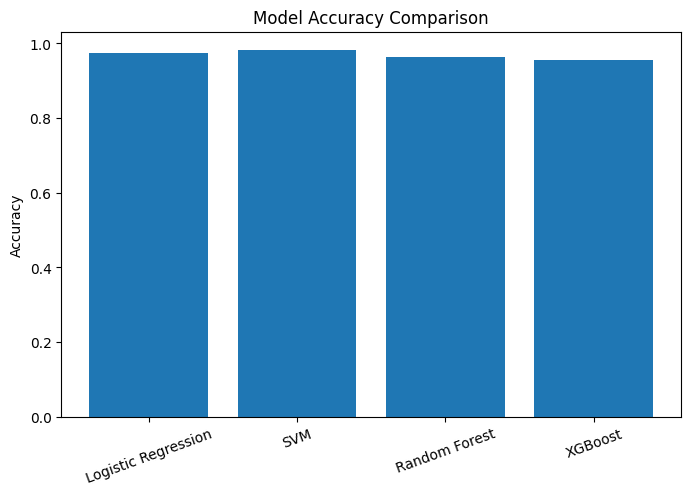

In [12]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Accuracy'])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

plt.show()

In [13]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(best_model)

Model            SVM
Accuracy    0.982456
Name: 1, dtype: object


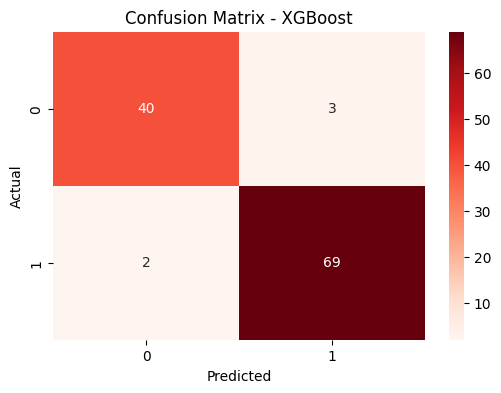

In [16]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [18]:
joblib.dump(
    xgb,
    "best_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [19]:
sample = X_test.iloc[0:1]

prediction = xgb.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Benign (Non-cancerous)")
else:
    print("Malignant (Cancerous)")

Prediction: 1
Benign (Non-cancerous)


In [20]:
sample = X_test.iloc[0:1]

actual = y_test.iloc[0]

prediction = xgb.predict(sample)[0]

print("Actual:", actual)
print("Predicted:", prediction)

Actual: 1
Predicted: 1


In [21]:
accuracy_score(y_test, xgb_pred)

0.956140350877193

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
27  worst concave points    0.286221
7    mean concave points    0.235468
22       worst perimeter    0.173798
20          worst radius    0.076194
23            worst area    0.056991
21         worst texture    0.021658
26       worst concavity    0.018631
12       perimeter error    0.018617
1           mean texture    0.014441
0            mean radius    0.012794


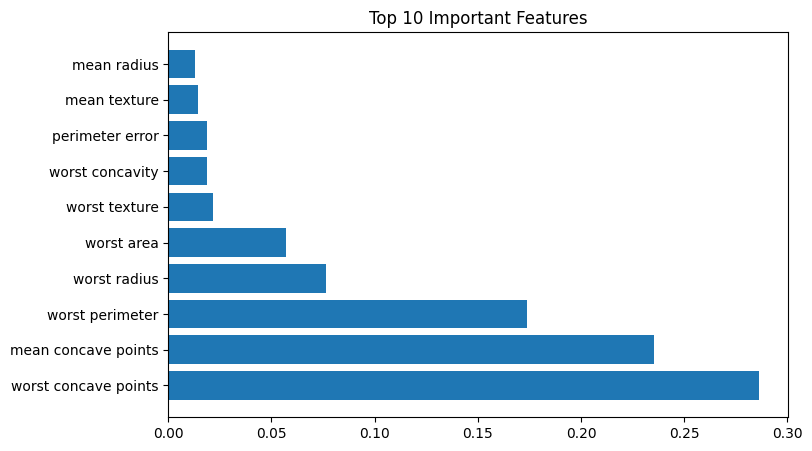

In [23]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.title("Top 10 Important Features")
plt.show()